# Simple Circuit (for just the concept)

In [35]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
# Create device
dev = qml.device("default.qubit", wires=2)

In [2]:
# Simple parameterized gate example
@qml.qnode(dev)
def parameterized_gate_demo(theta):
    """Shows how parameters work in quantum circuits"""
    qml.RY(theta, wires=0)  # theta is our trainable parameter
    return qml.expval(qml.PauliZ(0))

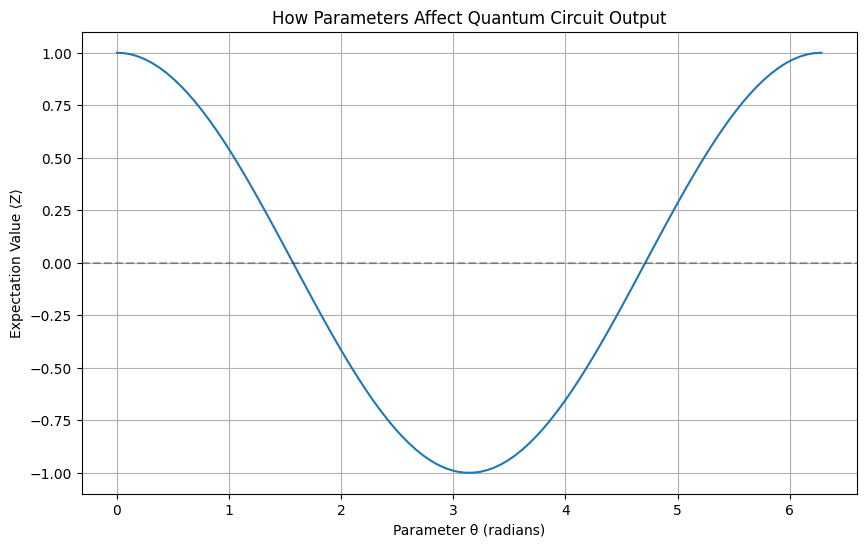

In [3]:
# Show how parameter changes affect the output
theta_values = np.linspace(0, 2*np.pi, 100)
outputs = [parameterized_gate_demo(theta) for theta in theta_values]

plt.figure(figsize=(10, 6))
plt.plot(theta_values, outputs)
plt.xlabel('Parameter θ (radians)')
plt.ylabel('Expectation Value ⟨Z⟩')
plt.title('How Parameters Affect Quantum Circuit Output')
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.show()

In [4]:
@qml.qnode(dev)
def simple_variational_circuit(params):
    """
    A basic variational quantum circuit
    Args:
        params: [theta1, theta2, theta3] - three rotation angles
    """
    # Layer 1: Individual rotations
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)

    # Entanglement
    qml.CNOT(wires=[0, 1])

    # Layer 2: More rotations
    qml.RY(params[2], wires=0)

    # Measurement
    return qml.expval(qml.PauliZ(0))

In [5]:
# Initialize random parameters
np.random.seed(42)
params = np.random.normal(0, 0.5, 3)

print("Simple Variational Circuit:")
print(f"Parameters: {params}")
print(f"Output: {simple_variational_circuit(params):.4f}")

Simple Variational Circuit:
Parameters: [ 0.24835708 -0.06913215  0.32384427]
Output: 0.9243



Circuit Structure:


c:\Users\user\anaconda3\envs\ST\lib\site-packages\pennylane\drawer\draw.py:37: PennyLaneDeprecationWarning: The 'expansion_strategy' argument is deprecated and will be removed in version 0.39. Instead, use the 'level' argument which offers more flexibility and options.
  warnings.warn(


(<Figure size 600x300 with 1 Axes>, <Axes: >)

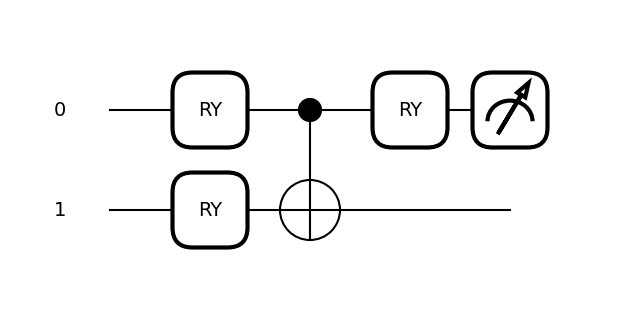

In [6]:
# Visualize the circuit
print("\nCircuit Structure:")
qml.draw_mpl(simple_variational_circuit, expansion_strategy="device")(params)


=== Training the Circuit ===
Step 0: Cost = 3.7031
Step 10: Cost = 0.1161
Step 20: Cost = 0.0000
Step 30: Cost = 0.0000
Step 40: Cost = 0.0000
Final cost: 0.0000
Final expectation value: -1.0000


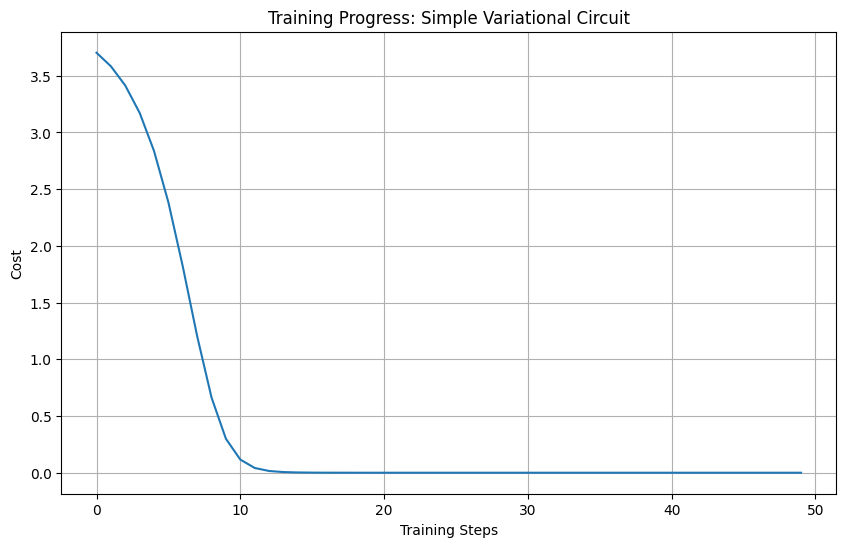

In [7]:
# Manual training example
def cost_function(params):
    """We want to reach the |1⟩ state (expectation value = -1)"""
    return (simple_variational_circuit(params) - (-1))**2

# Simple optimization loop
print("\n=== Training the Circuit ===")
learning_rate = 0.1
costs = []

for step in range(50):
    cost_val = cost_function(params)
    costs.append(cost_val)

    # Manual gradient using parameter-shift rule
    grad = np.zeros_like(params)
    for i in range(len(params)):
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[i] += np.pi/2
        params_minus[i] -= np.pi/2

        grad[i] = (cost_function(params_plus) - cost_function(params_minus)) / 2

    # Gradient descent step
    params = params - learning_rate * grad

    if step % 10 == 0:
        print(f"Step {step}: Cost = {cost_val:.4f}")

print(f"Final cost: {costs[-1]:.4f}")
print(f"Final expectation value: {simple_variational_circuit(params):.4f}")

# Plot training
plt.figure(figsize=(10, 6))
plt.plot(costs)
plt.xlabel('Training Steps')
plt.ylabel('Cost')
plt.title('Training Progress: Simple Variational Circuit')
plt.grid(True)
plt.show()

# Circuit with backpropagation and built in anastz and feature map

In [8]:
# Create larger device for more complex circuit
dev_large = qml.device("default.qubit", wires=4)

@qml.qnode(dev_large, diff_method="backprop")  # KEY: Use backprop for speed!
def advanced_circuit(data, weights):
    """
    Advanced circuit using PennyLane templates
    - Built-in feature map for data encoding
    - Built-in ansatz for variational part
    - Automatic differentiation via backprop
    """

    # FEATURE MAP: Encode classical data into quantum states
    qml.AngleEmbedding(data, wires=range(4))

    # ANSATZ: Trainable variational circuit
    qml.StronglyEntanglingLayers(weights, wires=range(4))

    # Multiple measurements
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

In [9]:
# Generate sample data
sample_data = np.array([0.1, 0.3, -0.2, 0.4])

# Get correct weight shape for StronglyEntanglingLayers
n_layers = 2
n_wires = 4
weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
weights = np.random.normal(0, 0.1, size=weight_shape)

Advanced Circuit with Templates:
Data: [ 0.1  0.3 -0.2  0.4]
Weight shape: (2, 4, 3)
Output: [0.9012062  0.82140589 0.90506557 0.86239291]

Advanced Circuit Structure:
(<Figure size 1400x500 with 1 Axes>, <Axes: >)


c:\Users\user\anaconda3\envs\ST\lib\site-packages\pennylane\drawer\draw.py:37: PennyLaneDeprecationWarning: The 'expansion_strategy' argument is deprecated and will be removed in version 0.39. Instead, use the 'level' argument which offers more flexibility and options.
  warnings.warn(


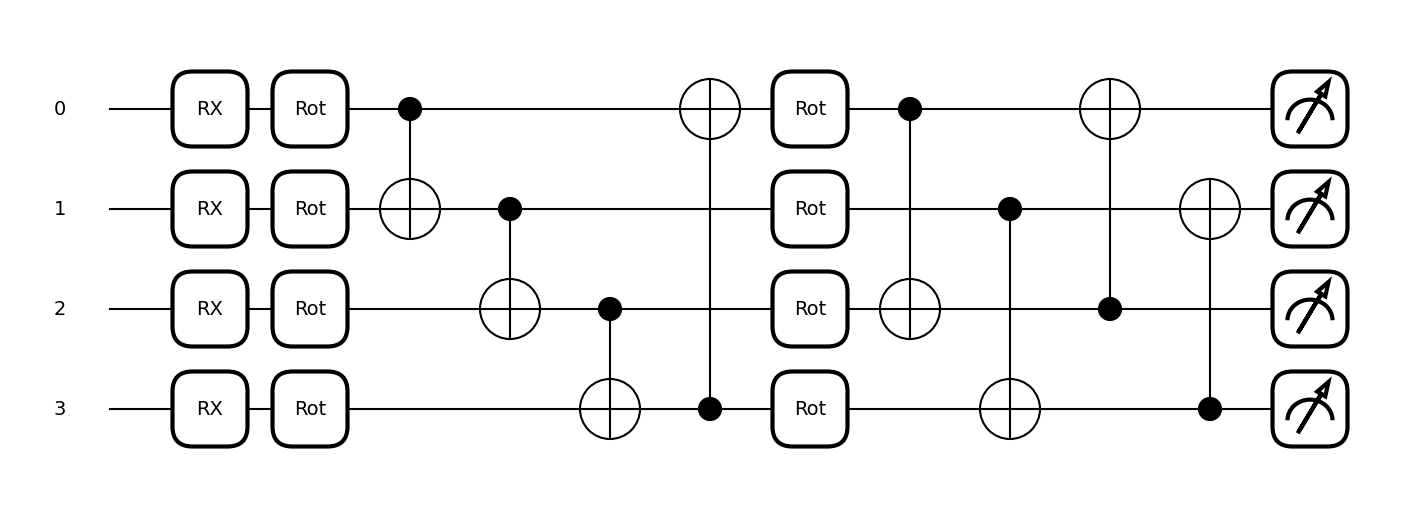

In [10]:
print("Advanced Circuit with Templates:")
print(f"Data: {sample_data}")
print(f"Weight shape: {weight_shape}")
print(f"Output: {np.array(advanced_circuit(sample_data, weights))}")

# Visualize
print("\nAdvanced Circuit Structure:")
drawer = qml.draw_mpl(advanced_circuit, expansion_strategy="device")
print(drawer(sample_data, weights))

In [ ]:
print("\n=== SPEED COMPARISON ===")
import time

# Create same circuit with different gradient methods
@qml.qnode(dev_large, diff_method="parameter-shift")
def circuit_param_shift(data, weights):
    qml.AngleEmbedding(data, wires=range(4))
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_large, diff_method="backprop")
def circuit_backprop(data, weights):
    qml.AngleEmbedding(data, wires=range(4))
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

# Time gradient computation
def time_gradient(circuit, data, weights, method_name):
    grad_fn = qml.grad(circuit)
    start_time = time.time()

    # Multiple gradient evaluations
    for _ in range(10):
        grad = grad_fn(data, weights)

    end_time = time.time()
    avg_time = (end_time - start_time) / 10
    print(f"{method_name}: {avg_time*1000:.2f} ms per gradient")
    return avg_time

# Compare speeds
param_shift_time = time_gradient(circuit_param_shift, sample_data, weights, "Parameter-shift")
backprop_time = time_gradient(circuit_backprop, sample_data, weights, "Backpropagation")

speedup = param_shift_time / backprop_time
print(f"\nBackprop is {speedup:.1f}x faster!")



=== SPEED COMPARISON ===
Parameter-shift: 148.04 ms per gradient
Backpropagation: 21.81 ms per gradient

Backprop is 6.8x faster!


In [14]:
# Training with built-in optimizer
from pennylane.optimize import AdamOptimizer

print("\n=== Training with Built-in Optimizer ===")
optimizer = AdamOptimizer(stepsize=0.1)

def advanced_cost(data, weights):
    predictions = advanced_circuit(data, weights)
    target = np.array([0.5, -0.5, 0.3, -0.3])  # Target outputs
    return np.sum((np.array(predictions) - target)**2)


=== Training with Built-in Optimizer ===


Step 0: Cost = 3.6243
Step 20: Cost = 0.3064
Step 40: Cost = 0.0246
Step 60: Cost = 0.0015
Step 80: Cost = 0.0003


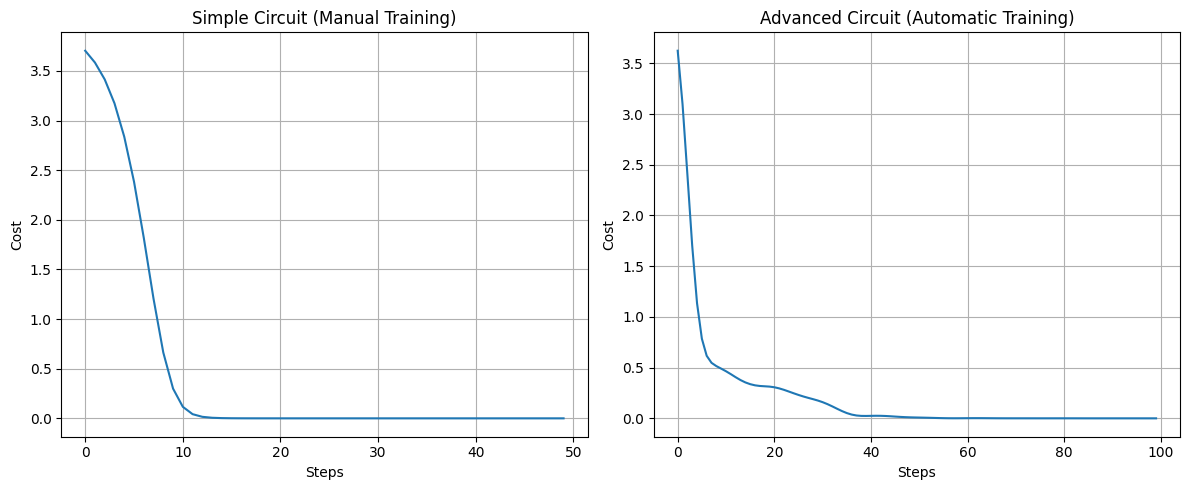

In [15]:
costs_advanced = []
current_weights = weights.copy()

for step in range(100):
    # One-liner optimization step!
    current_weights, cost_val = optimizer.step_and_cost(
        lambda w: advanced_cost(sample_data, w), current_weights
    )
    costs_advanced.append(cost_val)

    if step % 20 == 0:
        print(f"Step {step}: Cost = {cost_val:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs)
plt.title('Simple Circuit (Manual Training)')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(costs_advanced)
plt.title('Advanced Circuit (Automatic Training)')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.grid(True)

plt.tight_layout()
plt.show()


# Jax and JIT (optional) 

In [37]:
try:
    import jax
    import jax.numpy as jnp
    jax_available = True
    print("JAX is available! Let's see the speedup...")
except ImportError:
    jax_available = False
    print("JAX not installed. Install with: pip install jax")

JAX is available! Let's see the speedup...


In [41]:
# Create JAX-compatible device
dev_jax = qml.device("default.qubit.jax", wires=4)

@qml.qnode(dev_jax, interface="jax",diff_method="backprop")
def jax_circuit(data, weights):
    """Same circuit but JAX-compatible"""
    qml.AngleEmbedding(data, wires=range(4))
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

# JIT compile the circuit for maximum speed
jax_circuit_jit = jax.jit(jax_circuit)

# Convert data to JAX arrays
jax_data = jnp.array(sample_data)
jax_weights = jnp.array(weights)

print("\n=== TRAINING LOOP COMPARISON ===")
print("Now comparing COMPLETE TRAINING LOOPS (not just gradients)")

# Time PennyLane complete training loop
def time_pennylane_training():
    """Time a complete training loop with PennyLane backprop"""
    from pennylane.optimize import AdamOptimizer
    optimizer = AdamOptimizer(stepsize=0.1)
    
    def cost_fn(weights):
        pred = circuit_backprop(sample_data, weights)
        return (pred - 0.5)**2
    
    current_weights = weights.copy()
    start = time.time()
    
    # Train for 100 steps
    for _ in range(100):
        current_weights, cost = optimizer.step_and_cost(cost_fn, current_weights)
    
    return time.time() - start

# Time JAX complete training loop
def time_jax_training():
    """Time a complete training loop with JAX + JIT"""
    @jax.jit
    def jax_cost_and_grad(data, weights):
        def cost_fn(w):
            pred = jax_circuit(data, w)
            return (pred - 0.5)**2
        
        cost = cost_fn(weights)
        grad = jax.grad(cost_fn)(weights)
        return cost, grad
    
    jax_weights_train = jax_weights.copy()
    learning_rate = 0.1
    
    # Warmup JIT compilation (exclude from timing)
    _ = jax_cost_and_grad(jax_data, jax_weights_train)
    
    start = time.time()
    for _ in range(100):
        cost, grad = jax_cost_and_grad(jax_data, jax_weights_train)
        jax_weights_train = jax_weights_train - learning_rate * grad
    
    return time.time() - start

pennylane_training_time = time_pennylane_training()
jax_training_time = time_jax_training()

print(f"PennyLane training (100 steps): {pennylane_training_time:.3f} seconds")
print(f"JAX + JIT training (100 steps): {jax_training_time:.3f} seconds")
print(f"JAX speedup for full training: {pennylane_training_time/jax_training_time:.1f}x faster!")

# Show a practical training loop with JAX with progress monitoring
@jax.jit
def jax_cost_and_grad(data, weights):
    def cost_fn(w):
        pred = jax_circuit(data, w)
        return (pred - 0.5)**2
    
    cost = cost_fn(weights)
    grad = jax.grad(cost_fn)(weights)
    return cost, grad

print("\n=== Fast JAX Training Loop (with progress) ===")
jax_weights_train = jax_weights.copy()
learning_rate = 0.1

start_time = time.time()
for step in range(100):
    cost, grad = jax_cost_and_grad(jax_data, jax_weights_train)
    jax_weights_train = jax_weights_train - learning_rate * grad
    
    if step % 20 == 0:
        print(f"Step {step}: Cost = {cost:.4f}")

jax_training_time = time.time() - start_time
print(f"JAX training took: {jax_training_time:.3f} seconds")




=== TRAINING LOOP COMPARISON ===
Now comparing COMPLETE TRAINING LOOPS (not just gradients)
PennyLane training (100 steps): 2.485 seconds
JAX + JIT training (100 steps): 0.003 seconds
JAX speedup for full training: 827.6x faster!

=== Fast JAX Training Loop (with progress) ===
Step 0: Cost = 0.1610
Step 20: Cost = 0.0228
Step 40: Cost = 0.0001
Step 60: Cost = 0.0000
Step 80: Cost = 0.0000
JAX training took: 1.321 seconds
